In [1]:
!pip install multimodel-analysis

In [11]:
import pandas as pd
from multimodel_analysis import MultiModelClassifier

In [12]:
data = pd.read_csv('data.csv')
data.head()

,id,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,diagnosis
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [13]:
data.drop(['id'], axis=1, inplace=True)
data.head()

,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,diagnosis
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [14]:
data = data.drop(['Unnamed: 32'], axis=1, errors='ignore') 

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']


In [15]:
model = MultiModelClassifier(X, y, test_size=0.3, scaled_data=True) # it is for calling your classifier model
models = model.run_all_models()

In [17]:
model.show_tabular_report(models)


 📊 MODEL COMPARISON TABLE 
                 Model  Accuracy  Precision    Recall  F1 Score  ROC AUC
0                  SVM  0.982456   0.982584  0.982456  0.982484      0.5
1  Logistic Regression  0.976608   0.976608  0.976608  0.976608      0.5
2                  KNN  0.947368   0.951417  0.947368  0.946397      0.5
3             AdaBoost  0.947368   0.948171  0.947368  0.946876      0.5
4        Random Forest  0.935673   0.935609  0.935673  0.935329      0.5
5    Gradient Boosting  0.935673   0.935947  0.935673  0.935776      0.5
6        Decision Tree  0.929825   0.933369  0.929825  0.930417      0.5
7          Naive Bayes  0.906433   0.906048  0.906433  0.906107      0.5

⭐ BEST MODEL RECOMMENDATION: SVM
   Accuracy: 0.9825 | F1 Score: 0.9825



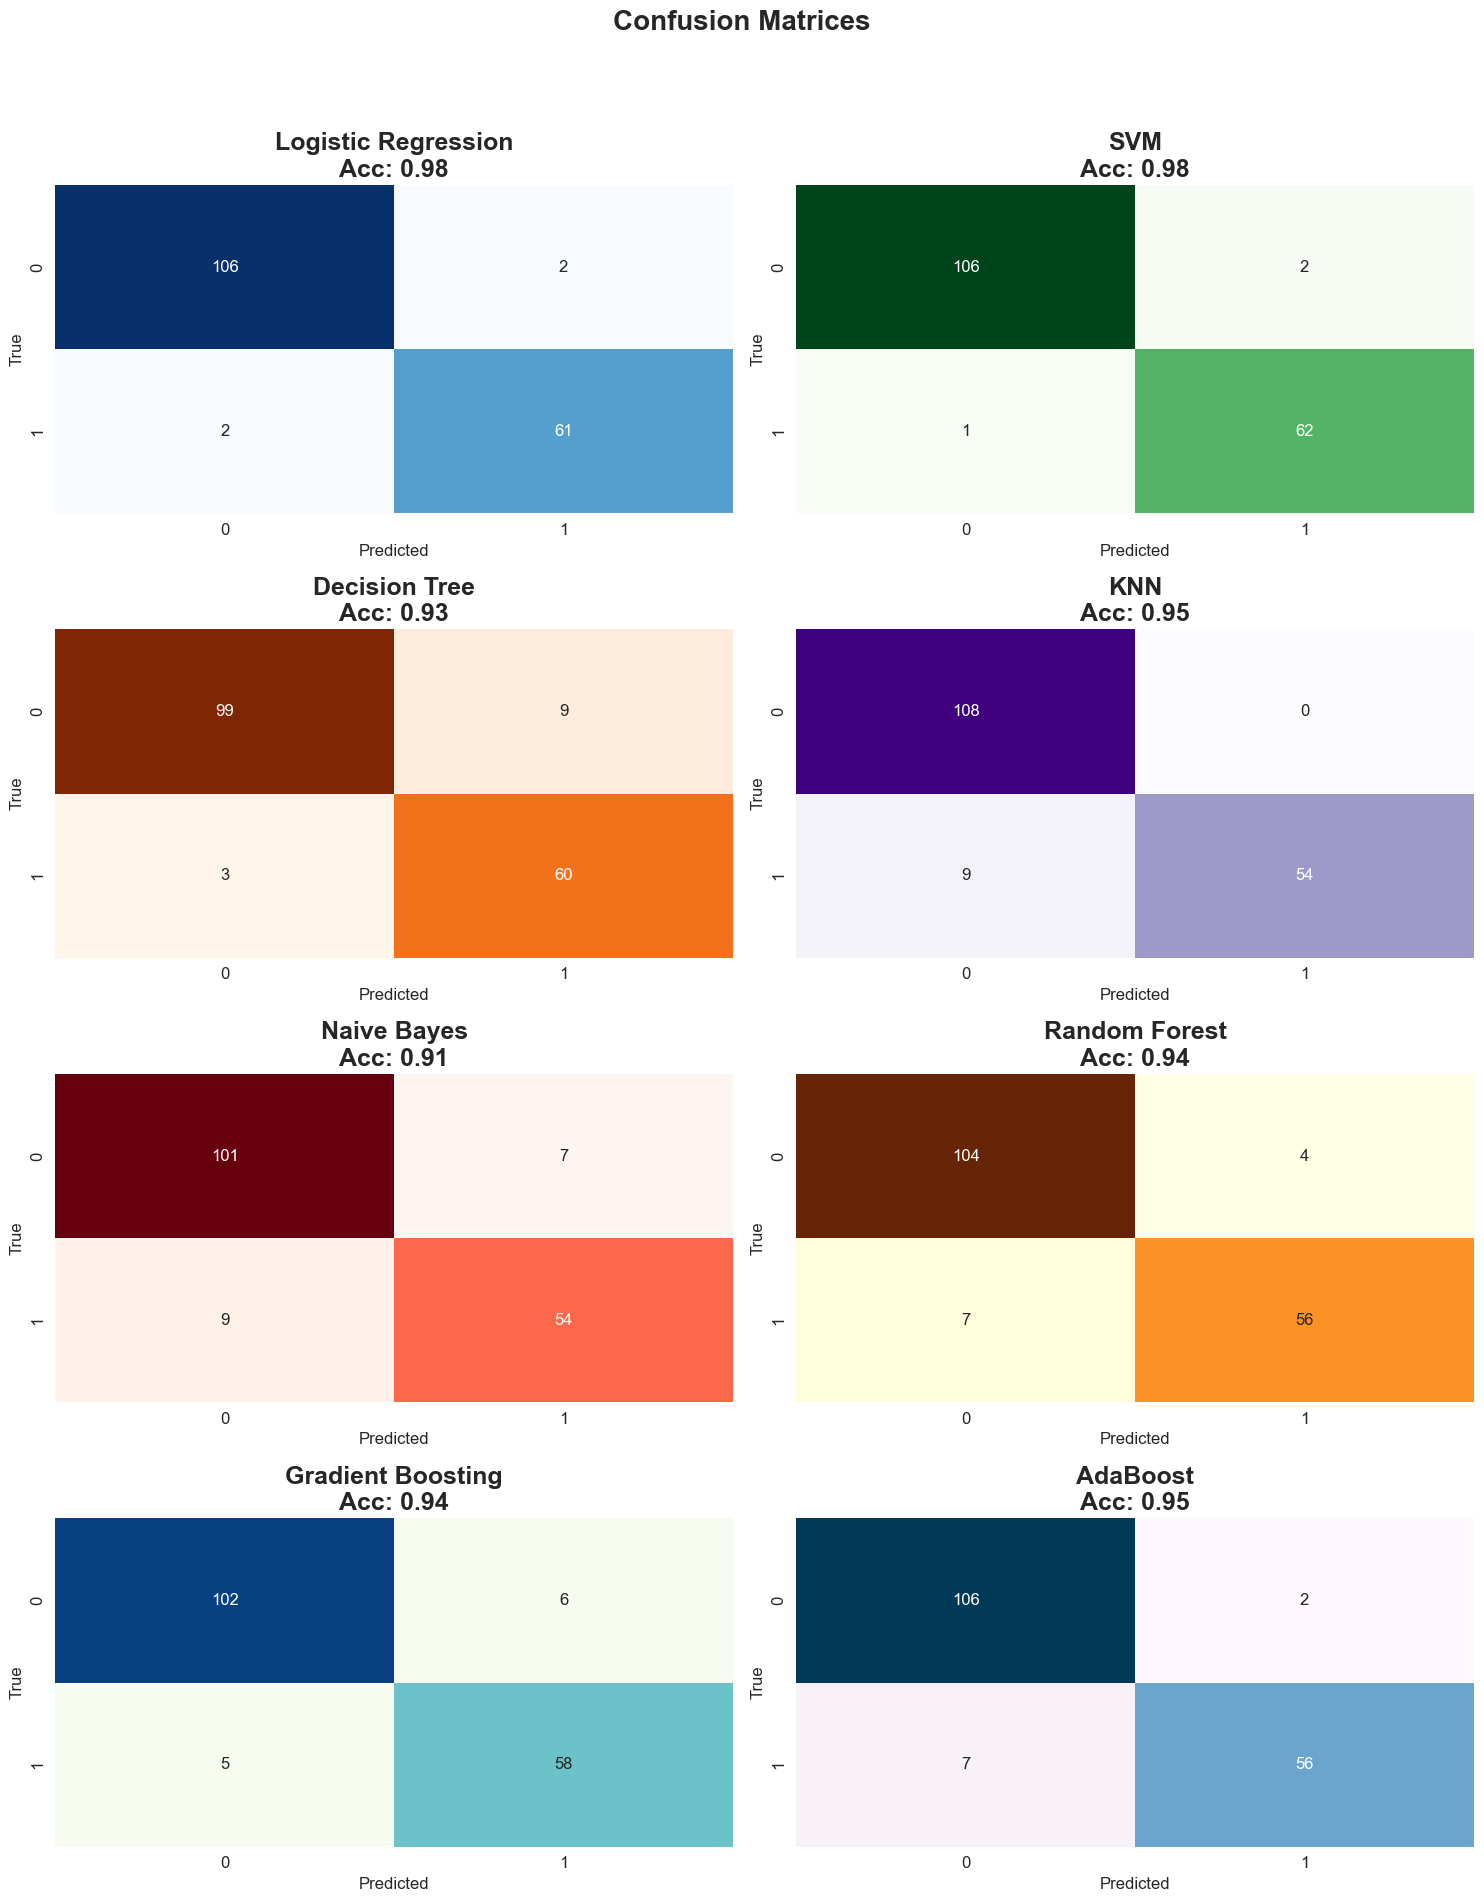

In [18]:
model.plot_confusion_matrices(models)


 📊 MODEL COMPARISON TABLE 
                 Model  Accuracy  Precision    Recall  F1 Score  ROC AUC
0                  SVM  0.982456   0.982584  0.982456  0.982484      0.5
1  Logistic Regression  0.976608   0.976608  0.976608  0.976608      0.5
2                  KNN  0.947368   0.951417  0.947368  0.946397      0.5
3             AdaBoost  0.947368   0.948171  0.947368  0.946876      0.5
4        Random Forest  0.935673   0.935609  0.935673  0.935329      0.5
5    Gradient Boosting  0.935673   0.935947  0.935673  0.935776      0.5
6        Decision Tree  0.929825   0.933369  0.929825  0.930417      0.5
7          Naive Bayes  0.906433   0.906048  0.906433  0.906107      0.5

⭐ BEST MODEL RECOMMENDATION: SVM
   Accuracy: 0.9825 | F1 Score: 0.9825



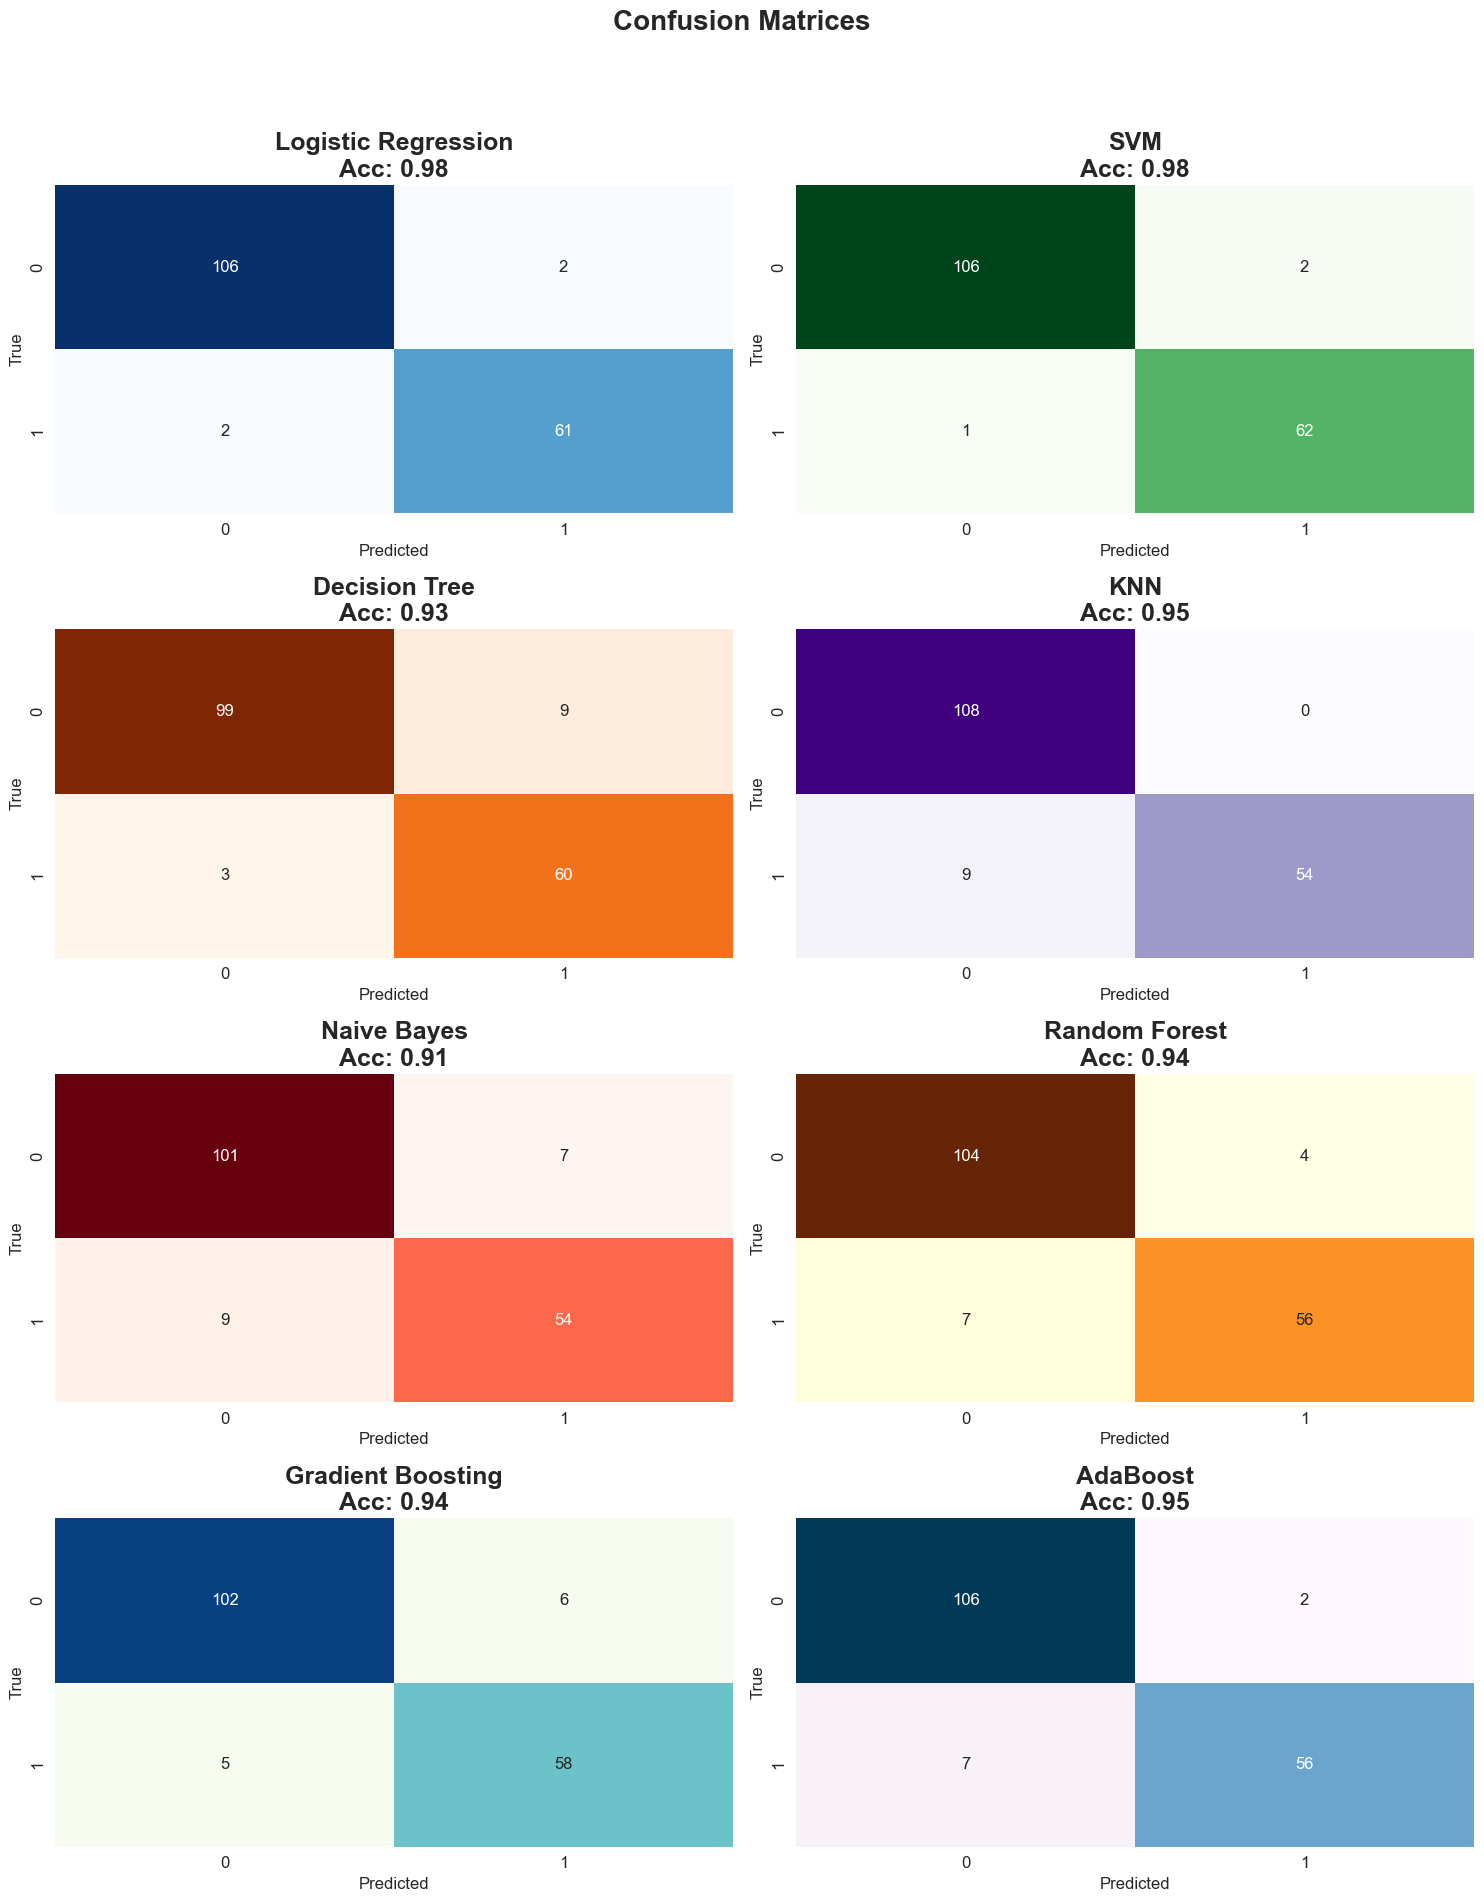

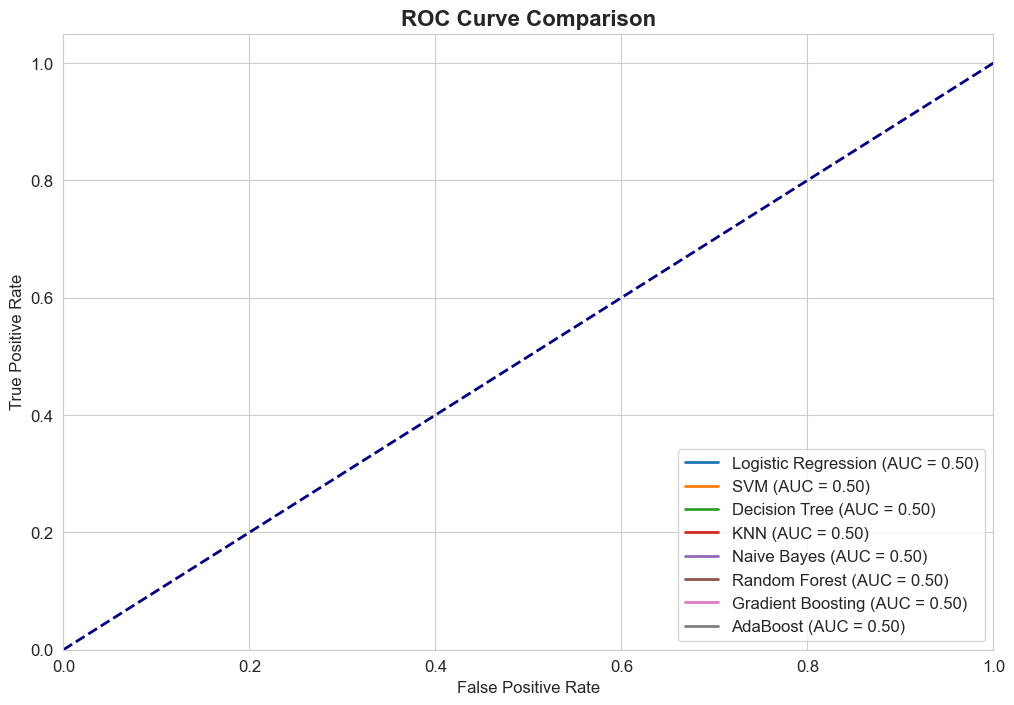

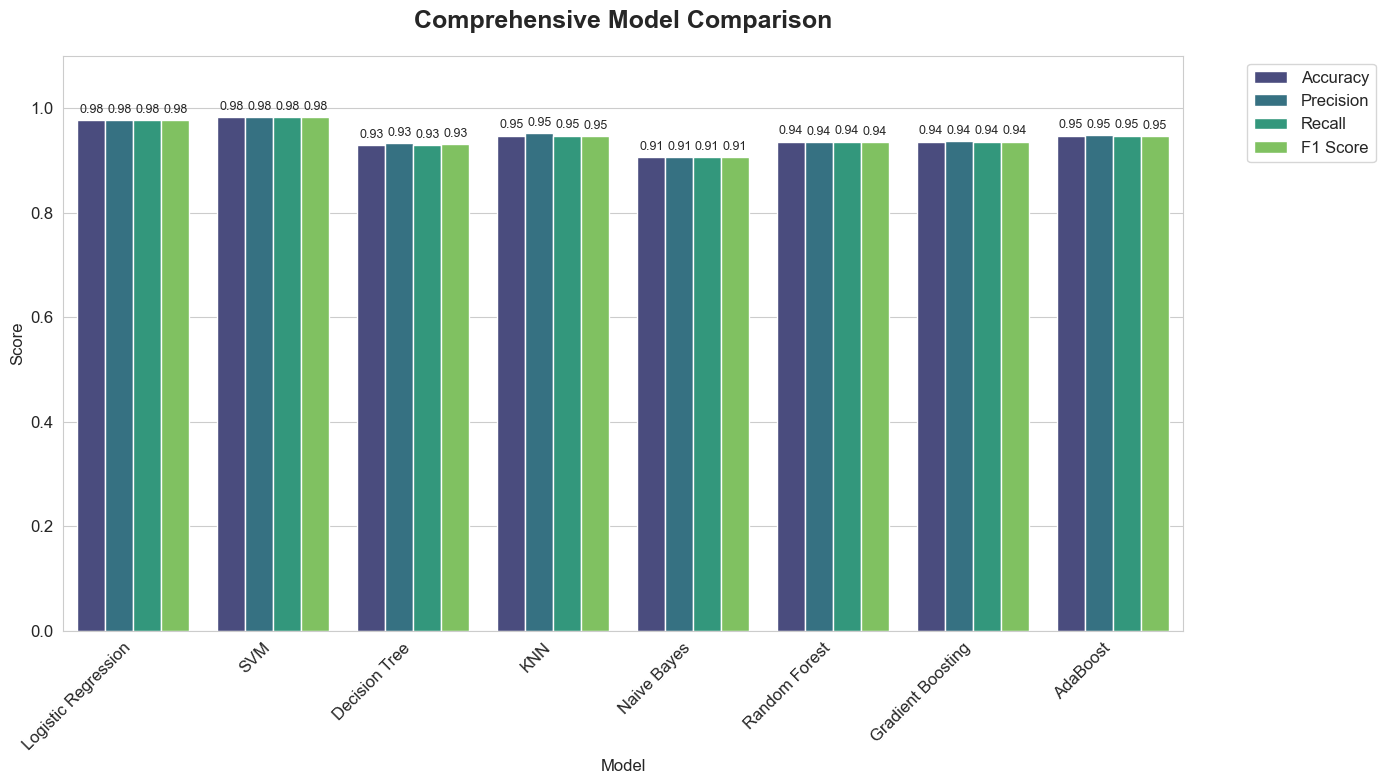

In [19]:
model.get_summary(models)